# qvarnet — the new API

A short tour after the foundation refactor (roadmap §0 + steps 1–2, plus minSR):

- **Packages**: method code in `vmc/`, the shared QGT in `geometry/`, empty
  `diagnostics/` and `observables/` for later steps.
- **`MetricsHistory`**: per-epoch struct-of-arrays — stacked fields, **per-chain**
  energies, and *no parameters* (the old per-epoch `VMCState` was a memory bomb).
- **SR is a preconditioner** that feeds optax, so `state.step` advances and learning-rate
  schedules work; there's also a new **`minsr`** solver (M-by-M Gram dual).

Test system: `N = 4` non-interacting particles in a 1D harmonic trap (omega = 1),
exact ground state `E0 = N/2 = 2.0`.

In [1]:
import jax
import numpy as np
import optax
from flax import linen as nn
import matplotlib.pyplot as plt

from qvarnet.models.mlp import MLP
from qvarnet.models.compose import LogWavefunction
from qvarnet.boundaries import NoBoundary
from qvarnet.hamiltonian.continuous import HarmonicOscillatorHamiltonian
from qvarnet.config.training_setup import TrainingConfig
from qvarnet.geometry.qgt import QGTConfig
from qvarnet.train import train

print("jax backend:", jax.default_backend())

jax backend: gpu


## 1. Build a log-wavefunction

Models output `log|psi|`. `LogWavefunction` composes a coordinate transform with a network;
a plain `MLP` takes the flat coordinates directly (set `n_particles` only for `DeepSet`).

In [2]:
N_PARTICLES, N_DIM = 4, 1
DOF = N_PARTICLES * N_DIM
E0_EXACT = N_PARTICLES * 0.5

model = LogWavefunction(
    network=MLP(hidden=[32, 32], output_dim=1, hidden_activation=nn.tanh),
    transform=NoBoundary(),
)
hamiltonian = HarmonicOscillatorHamiltonian(omega=1.0)
sampler_params = dict(step_size=0.5, chain_length=200, thermalization_steps=50, thinning_factor=2)

## 2. Train (Adam) and inspect the result

In [3]:
result = train(
    shape=(256, DOF),
    model=model,
    optimizer=optax.adam(1e-2),
    hamiltonian=hamiltonian,
    training_config=TrainingConfig(n_epochs=400, rng_seed=0, checkpoint_path="./_newapi_out"),
    sampler_params=sampler_params,
)
result

100%|██████████| 400/400 [00:05<00:00, 69.15it/s, E=2.0225, sigma_E=0.3716] 


TrainResult(n_steps=400, last_energy=2.031706)

## 3. The `MetricsHistory`

`result.history` is a struct-of-arrays: iterate it for per-epoch records
(`s.energy`, `s.std`, ...), or stack a field with `history.get(field)`. It also carries the
naive MC error of the mean and the **per-chain** energies needed for the step-4 diagnostics.

In [4]:
hist = result.history
energy = hist.get("energy")
err = hist.get("error_of_mean")
E_chain = hist.get("E_chain")          # (n_epochs, n_chains)

print("epochs:", len(hist))
print("E_chain shape (epochs, chains):", E_chain.shape)
print(f"final energy: {energy[-1]:.4f}  +/- {err[-1]:.4f} (SEM)   exact: {E0_EXACT}")

best = result.best(n=1, metric="energy")[0]
print("best-epoch energy:", float(best.energy))

epochs: 400
E_chain shape (epochs, chains): (400, 256)
final energy: 2.0317  +/- 0.0033 (SEM)   exact: 2.0
best-epoch energy: 2.018462657928467


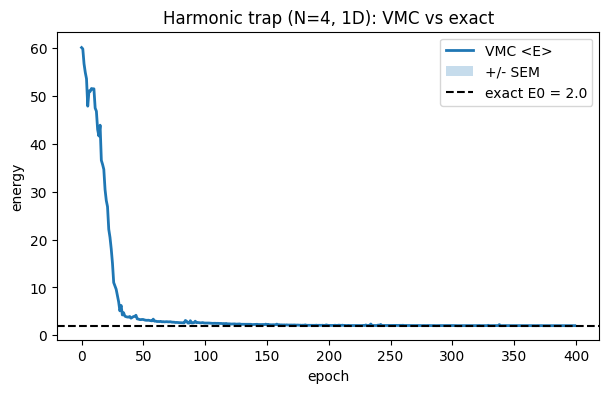

In [5]:
ep = np.arange(len(energy))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ep, energy, lw=2, label="VMC <E>")
ax.fill_between(ep, energy - err, energy + err, alpha=0.25, label="+/- SEM")
ax.axhline(E0_EXACT, ls="--", color="k", label=f"exact E0 = {E0_EXACT}")
ax.set_xlabel("epoch"); ax.set_ylabel("energy")
ax.set_title("Harmonic trap (N=4, 1D): VMC vs exact"); ax.legend()
plt.show()

## 4. Per-chain energies

Each epoch stores one mean local energy per MCMC chain — the input to split-Rhat /
Geweke stationarity tests (diagnostics land in step 4).

In [6]:
last = result.history[-1]
print("per-chain E (last epoch, first 8):", np.round(np.asarray(last.E_chain)[:8], 3))
print("acceptance per chain (first 8):   ", np.round(np.asarray(last.acceptance_rate)[:8], 3))

per-chain E (last epoch, first 8): [1.959 2.015 2.015 2.011 2.015 1.97  2.215 2.009]
acceptance per chain (first 8):    [0.5   0.5   0.555 0.575 0.57  0.52  0.505 0.5  ]


## 5. Stochastic reconfiguration & minSR

`use_qgt=True` runs SR as a preconditioner that feeds optax (so the SGD learning rate is the
imaginary-time step and `state.step` advances). `solver="minsr"` solves the **M-by-M** Gram dual
instead of the **P-by-P** QGT — the *same* step (an exact identity), cheaper when `P > M`. Here
`P` is ~1.2k, so full SR is the economical choice; we run both to show they land together.
SR likes gentle steps and a little damping.

In [7]:
# A modest sample count keeps the M-by-M minSR system small.
sr_sampler = dict(step_size=0.5, chain_length=120, thermalization_steps=20, thinning_factor=4)

def run_sr(solver):
    return train(
        shape=(64, DOF),
        model=model,
        optimizer=optax.sgd(0.02),  # overridden by SGD(qgt lr) on the QGT path
        hamiltonian=hamiltonian,
        training_config=TrainingConfig(
            n_epochs=150, rng_seed=0, use_qgt=True, checkpoint_path="./_newapi_out"
        ),
        qgt_config=QGTConfig(solver=solver, learning_rate=0.02, regularization=1e-2),
        sampler_params=sr_sampler,
    )

res_sr = run_sr("cholesky")
res_minsr = run_sr("minsr")
print(f"full SR (cholesky) final: {float(res_sr.history[-1].energy):.4f}")
print(f"minSR              final: {float(res_minsr.history[-1].energy):.4f}")
print(f"exact E0:                 {E0_EXACT}")

100%|██████████| 150/150 [00:02<00:00, 50.54it/s, E=2.0071, sigma_E=0.1857] 

full SR (cholesky) final: 1.9985
minSR              final: 2.0074
exact E0:                 2.0


## Summary

- One `train()` call returns a `TrainResult` wrapping a `MetricsHistory` (per-epoch records,
  stacked-array accessors, per-chain energies, `best()`), with **no per-epoch parameter copies**.
- SR (`use_qgt=True`) is a preconditioner; `minsr` is its Gram-dual twin for `P > M`.
- Next on the roadmap: step 3 (discrete TFIM testbed) -> step 4 (the three-referee diagnostics
  that consume the per-chain energies shown above).